# Product Market Fit Analysis – E-commerce Dataset

## Objective
The goal of this project is to analyze customer purchasing behavior, product demand, and customer satisfaction to determine product-market fit in an e-commerce platform.

## Dataset
Brazilian E-Commerce Public Dataset by Olist.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [2]:
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


Upload DataSet


In [3]:
import os

os.listdir(path)

['olist_customers_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_geolocation_dataset.csv',
 'product_category_name_translation.csv',
 'olist_orders_dataset.csv',
 'olist_order_payments_dataset.csv']

Import Libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
orders = pd.read_csv(path + "/olist_orders_dataset.csv")
customers = pd.read_csv(path + "/olist_customers_dataset.csv")
order_items = pd.read_csv(path + "/olist_order_items_dataset.csv")
products = pd.read_csv(path + "/olist_products_dataset.csv")
reviews = pd.read_csv(path + "/olist_order_reviews_dataset.csv")
payments = pd.read_csv(path + "/olist_order_payments_dataset.csv")

Check Dataset Structure

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [9]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Convert Data Column


In [10]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

Month Column


In [11]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

Merge Tables


In [12]:
df = orders.merge(order_items, on='order_id')
df = df.merge(products, on='product_id')
df = df.merge(reviews, on='order_id')
df = df.merge(customers, on='customer_id')

In [13]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,order_item_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,1,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,1,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,1,...,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,1,...,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,1,...,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


Sales Trend Analysis

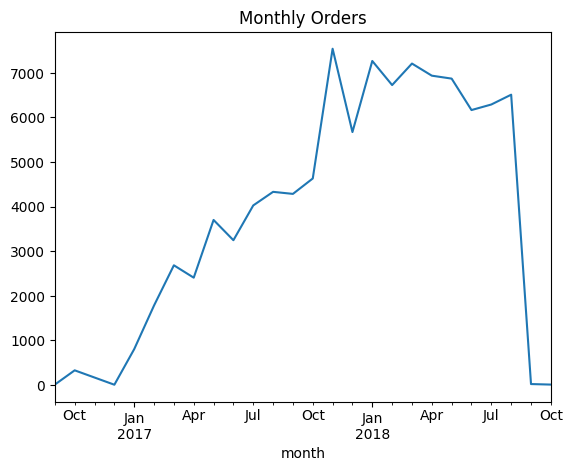

In [14]:
orders.groupby('month')['order_id'].count().plot()
plt.title("Monthly Orders")
plt.show()

Top Product Categories


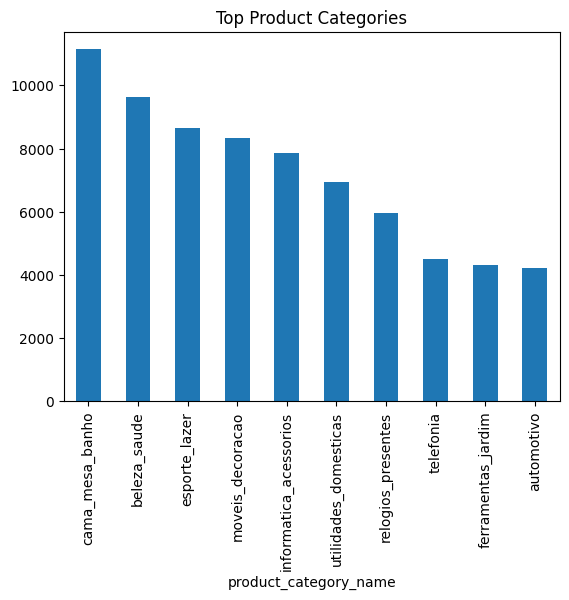

In [15]:
df['product_category_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top Product Categories")
plt.show()

Total Revenue Generated

In [18]:
df['revenue'] = df['price'] + df['freight_value']

total_revenue = df['revenue'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 15772164.690000001


Monthly Sales Trend

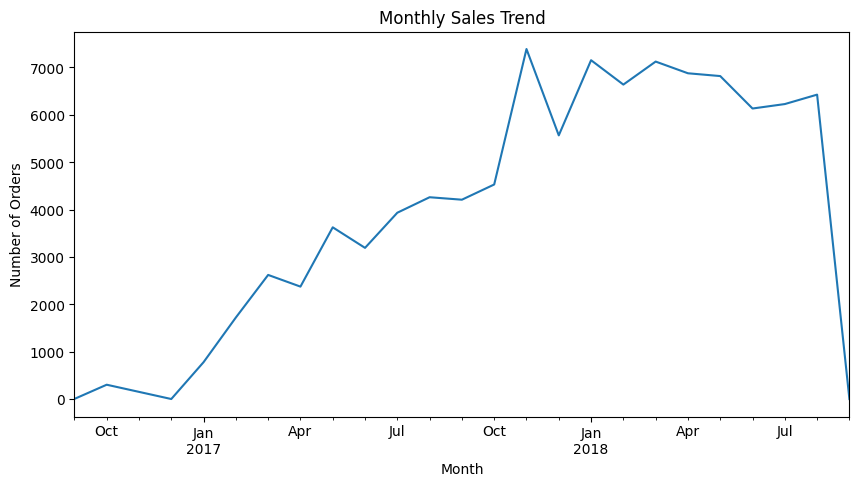

In [19]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = df.groupby('month')['order_id'].nunique()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

Product Categories with Most Orders

In [20]:
top_categories_orders = df['product_category_name'].value_counts().head(10)

print(top_categories_orders)

product_category_name
cama_mesa_banho           11137
beleza_saude               9645
esporte_lazer              8640
moveis_decoracao           8331
informatica_acessorios     7849
utilidades_domesticas      6943
relogios_presentes         5950
telefonia                  4517
ferramentas_jardim         4329
automotivo                 4213
Name: count, dtype: int64


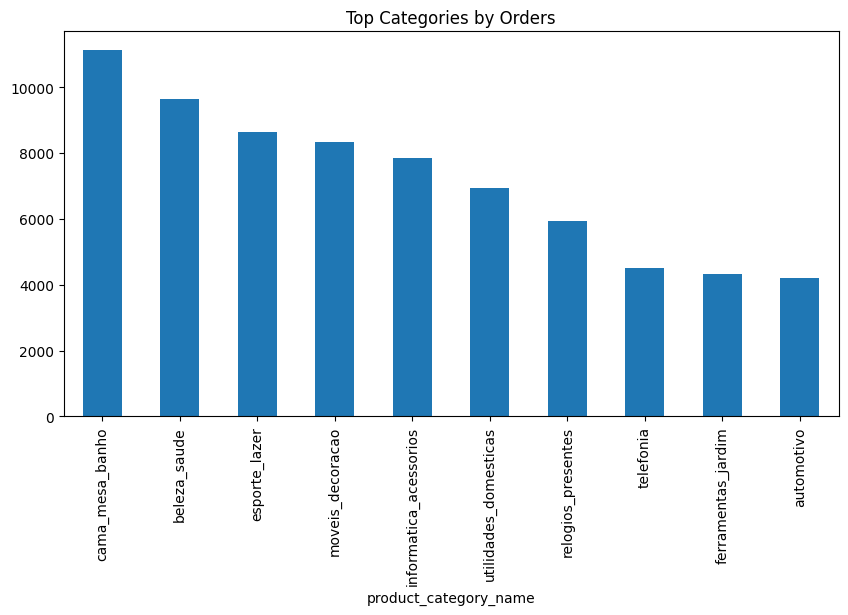

In [21]:
top_categories_orders.plot(kind='bar', figsize=(10,5))
plt.title("Top Categories by Orders")
plt.show()

Categories with Highest Revenue

In [22]:
category_revenue = df.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False).head(10)

print(category_revenue)

product_category_name
beleza_saude              1434501.78
relogios_presentes        1297404.23
cama_mesa_banho           1244950.00
esporte_lazer             1155295.28
informatica_acessorios    1062184.42
moveis_decoracao           902472.18
utilidades_domesticas      775827.36
cool_stuff                 712954.07
automotivo                 678859.45
ferramentas_jardim         581483.25
Name: revenue, dtype: float64


Customer Retention Rate

In [30]:
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

repeat_customers = (customer_orders > 1).sum()

total_customers = customer_orders.count()

retention_rate = repeat_customers / total_customers

print("Customer Retention Rate:", retention_rate)

Customer Retention Rate: 0.030288953875064663


Cities with Most Orders

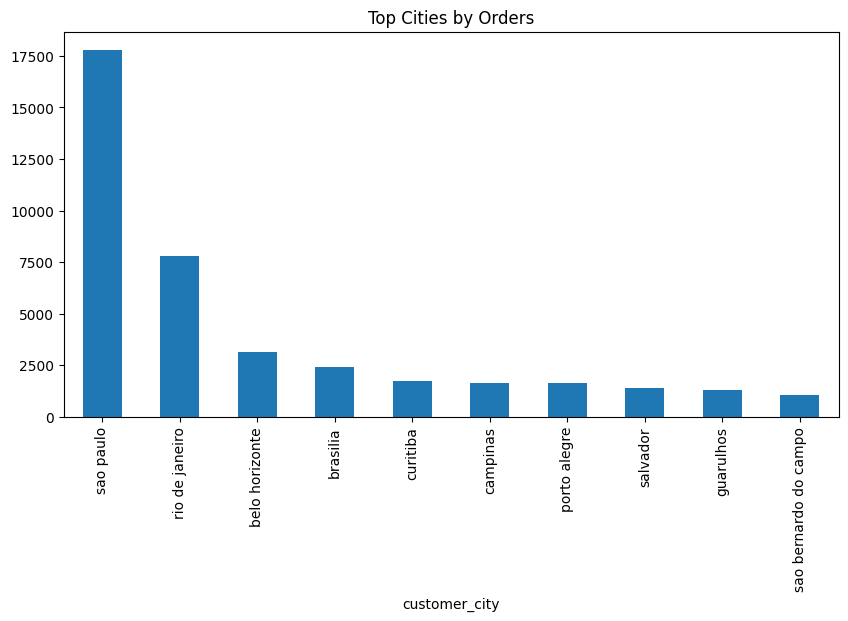

In [25]:
top_cities = df['customer_city'].value_counts().head(10)
top_cities.plot(kind='bar', figsize=(10,5))
plt.title("Top Cities by Orders")
plt.show()

Categories with Highest Ratings

In [26]:
highest_rated = df.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False).head(10)

print(highest_rated)

product_category_name
cds_dvds_musicais                     4.642857
fashion_roupa_infanto_juvenil         4.500000
livros_interesse_geral                4.446266
construcao_ferramentas_ferramentas    4.444444
flores                                4.419355
livros_importados                     4.400000
livros_tecnicos                       4.368421
alimentos_bebidas                     4.315412
malas_acessorios                      4.315257
portateis_casa_forno_e_cafe           4.302632
Name: review_score, dtype: float64


Categories with Low Ratings but High Sales

In [27]:
category_stats = df.groupby('product_category_name').agg(
    orders=('order_id','count'),
    avg_rating=('review_score','mean')
)

low_rating_high_sales = category_stats.sort_values(by='orders', ascending=False)

print(low_rating_high_sales.head(10))

                        orders  avg_rating
product_category_name                     
cama_mesa_banho          11137    3.895663
beleza_saude              9645    4.142768
esporte_lazer             8640    4.107986
moveis_decoracao          8331    3.903493
informatica_acessorios    7849    3.930819
utilidades_domesticas     6943    4.055019
relogios_presentes        5950    4.019160
telefonia                 4517    3.946867
ferramentas_jardim        4329    4.042735
automotivo                4213    4.065512


Most Used Payment Methods

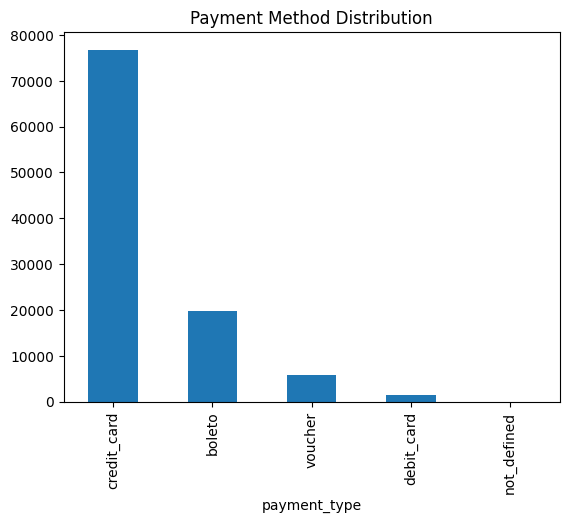

In [28]:
payment_methods = payments['payment_type'].value_counts()
payment_methods.plot(kind='bar')
plt.title("Payment Method Distribution")
plt.show()

Average Order Value (AOV)

In [29]:
order_revenue = df.groupby('order_id')['revenue'].sum()

average_order_value = order_revenue.mean()

print("Average Order Value:", average_order_value)

Average Order Value: 161.07687827445696


Export Data for Dashboard

In [32]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)